# Rossmann Store Sales: Machine Learning Forecasting

Initial Imports

In [570]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Data Loading

In [571]:
train = pd.read_csv("../data/raw/train.csv")
train.head()

C:\Users\prade\AppData\Local\Temp\ipykernel_24144\1810043436.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [572]:
print("Train shape:", train.shape)

Train shape: (1017209, 9)


## 2. Data Preparation

In [573]:
# date is currently obj convert to datetime
train["Date"] = pd.to_datetime(train["Date"])
train = train.sort_values("Date").reset_index(drop=True)

# Aggregate daily sales across all stores to match Phase 2 target
df = train.groupby("Date").agg(
    Sales=("Sales", "sum"),
    Promo=("Promo", "sum"),  # Number of stores running promo on that date
    SchoolHoliday=("SchoolHoliday", "sum"),  # Number of stores affected by school holiday
    StateHoliday_Count=("StateHoliday", lambda x: ((x != "0") & (x != 0)).sum()) # Number of stores with state holiday
).reset_index()

df = df.sort_values("Date").reset_index(drop=True)
df.sample(5)

,Date,Sales,Promo,SchoolHoliday,StateHoliday_Count
858,2015-05-09,7157061,0,0,0
378,2014-01-14,5785842,0,0,0
239,2013-08-28,7838558,1115,595,0
569,2014-07-24,5179026,0,688,0
774,2015-02-14,6701361,0,0,0


## 3. Store-Level Features

In [574]:
print("Daily aggregated dataset shape:", df.shape)
df.sample(5)

Daily aggregated dataset shape: (942, 5)


,Date,Sales,Promo,SchoolHoliday,StateHoliday_Count
549,2014-07-04,6518718,935,0,0
320,2013-11-17,194615,0,0,0
582,2014-08-06,6709611,935,935,0
518,2014-06-03,9598519,1115,56,0
547,2014-07-02,7708595,935,0,0


##### train.csv gives us the daily sales history and daily variables like:

* Promo

* StateHoliday 

* SchoolHoliday

When aggregating across all stores, these become daily network-level counts (e.g. number of stores running promotions, number of stores on holiday) that drive total chain sales

## 4. Calendar Features

In [575]:
# time based data extracted for certain dates
df["DayOfWeek_Num"] = df["Date"].dt.dayofweek
df["DayOfWeek"] = df["Date"].dt.dayofweek + 1
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["DayOfMonth"] = df["Date"].dt.day

df[[
    "Date",
    "DayOfWeek",
    "DayOfWeek_Num",
    "Month",
    "Year",
    "DayOfMonth"
]].sample(5)

,Date,DayOfWeek,DayOfWeek_Num,Month,Year,DayOfMonth
609,2014-09-02,2,1,9,2014,2
294,2013-10-22,2,1,10,2013,22
204,2013-07-24,3,2,7,2013,24
880,2015-05-31,7,6,5,2015,31
335,2013-12-02,1,0,12,2013,2


##### DayOfWeek_Num: Monday 0 through Sunday 6 

Month: captures monthly patterns

Year: captures longer-term changes

DayOfMonth: can capture patterns around the beginning/end of a month

## 5. Lag Features

In [576]:
# yesterday's sales
df["Sales_Lag_1"] = df["Sales"].shift(1)
# sales 7 days ago (same day but 1 weeks ago)
df["Sales_Lag_7"] = df["Sales"].shift(7)
# sales 14 days ago (same day but 2 weeks ago)
df["Sales_Lag_14"] = df["Sales"].shift(14)

df[[
    "Date",
    "Sales",
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Sales_Lag_14"
]].head(21)
"""
if retail sales were high yesterday and usually high on the same weekday last week,
today's sales may also be high
"""

"\nif retail sales were high yesterday and usually high on the same weekday last week,\ntoday's sales may also be high\n"

Lag features allow an ML model to use past sales, similar to how ARIMA uses previous observations, but the ML model can combine them with Promo, holidays, store type, and many other features

## 6. Rolling Features

In [577]:
# The average of last 7 days sales values
df["Sales_Rolling_Mean_7"] = (
    df["Sales"].shift(1).rolling(window=7).mean()
)
# The average of last 14 days sales values
df["Sales_Rolling_Mean_14"] = (
    df["Sales"].shift(1).rolling(window=14).mean() 
)

df[[
    "Date",
    "Sales",
    "Sales_Rolling_Mean_7",
    "Sales_Rolling_Mean_14"
]].head(21)

,Date,Sales,Sales_Rolling_Mean_7,Sales_Rolling_Mean_14
0,2013-01-01,97235,NaN,NaN
1,2013-01-02,6949829,NaN,NaN
2,2013-01-03,6347820,NaN,NaN
3,2013-01-04,6638954,NaN,NaN
4,2013-01-05,5951593,NaN,NaN
5,2013-01-06,143904,NaN,NaN
6,2013-01-07,10826848,NaN,NaN
7,2013-01-08,8749437,5.279455e+06,NaN
8,2013-01-09,7746603,6.515484e+06,NaN
9,2013-01-10,7751485,6.629308e+06,NaN


## 7. Missing Values from Time-Based Features

In [578]:
time_features = [
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Sales_Lag_14",
    "Sales_Rolling_Mean_7",
    "Sales_Rolling_Mean_14"
]

df[time_features].isnull().sum()

Sales_Lag_1               1
Sales_Lag_7               7
Sales_Lag_14             14
Sales_Rolling_Mean_7      7
Sales_Rolling_Mean_14    14
dtype: int64

The initial observations have NaNs: lag_1 = 1, lag_7 = 7, and lag_14 = 14

Drop the null values since there is'nt enough historical sales data

In [579]:
df = df.dropna(subset=time_features).reset_index(drop=True)
print(df.shape)
df[time_features].isnull().sum()

(928, 15)


Sales_Lag_1              0
Sales_Lag_7              0
Sales_Lag_14             0
Sales_Rolling_Mean_7     0
Sales_Rolling_Mean_14    0
dtype: int64

We only remove the first 14 observations from the time series, where the required historical information does not exist (Nan)

## 8. Business and Store Features

In [580]:
business_features = [
    "Promo",
    "SchoolHoliday",
    "StateHoliday_Count"
]

df[business_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 928 entries, 0 to 927
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Promo               928 non-null    int64
 1   SchoolHoliday       928 non-null    int64
 2   StateHoliday_Count  928 non-null    int64
dtypes: int64(3)
memory usage: 21.9 KB


In [581]:
df[business_features].isnull().sum()

Promo                 0
SchoolHoliday         0
StateHoliday_Count    0
dtype: int64

In [582]:
df.head()

,Date,Sales,Promo,SchoolHoliday,StateHoliday_Count,DayOfWeek_Num,DayOfWeek,Month,Year,DayOfMonth,Sales_Lag_1,Sales_Lag_7,Sales_Lag_14,Sales_Rolling_Mean_7,Sales_Rolling_Mean_14
0,2013-01-15,5512591,0,0,0,1,2,1,2013,15,5886788.0,8749437.0,97235.0,6.333595e+06,5.806525e+06
1,2013-01-16,5293020,0,0,0,2,3,1,2013,16,5512591.0,7746603.0,6949829.0,5.871188e+06,6.193336e+06
2,2013-01-17,5386564,0,0,0,3,4,1,2013,17,5293020.0,7751485.0,6347820.0,5.520676e+06,6.074992e+06
3,2013-01-18,6137010,0,0,0,4,5,1,2013,18,5386564.0,8039306.0,6638954.0,5.182830e+06,6.006331e+06
4,2013-01-19,6010192,0,0,0,5,6,1,2013,19,6137010.0,6017491.0,5951593.0,4.911074e+06,5.970478e+06


## 9. Feature and Target Selection

In [583]:
target = "Sales"

features = [
    "DayOfWeek",
    "Promo",
    "SchoolHoliday",
    "StateHoliday_Count",
    "DayOfWeek_Num",
    "Month",
    "Year",
    "DayOfMonth",
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Sales_Lag_14",
    "Sales_Rolling_Mean_7",
    "Sales_Rolling_Mean_14"
]

X = df[features]
y = df[target]

print("Number of features:", len(features))
print("X shape:", X.shape) # values of all above columns
print("y shape:", y.shape) # Sales Actual



Number of features: 13
X shape: (928, 13)
y shape: (928,)


## 10. Train-Test Split

In [584]:
# Exact same 60-day test set as Phase 2
test_size = 60

test_mask = df.index >= (len(df) - test_size)
train_mask = ~test_mask

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

"""
Training data: 868 daily observations
Testing data:  60 daily observations
Test Period:   2015-06-02 to 2015-07-31
"""

Training shape: (868, 13)
Testing shape: (60, 13)


'\nTraining data: 868 daily observations\nTesting data:  60 daily observations\nTest Period:   2015-06-02 to 2015-07-31\n'

In [585]:
# Verify the dates are split correctly
print("Training period:")
print(
    df.loc[train_mask, "Date"].min(),
    "to",
    df.loc[train_mask, "Date"].max()
)

print("\nTesting period:")
print(
    df.loc[test_mask, "Date"].min(),
    "to",
    df.loc[test_mask, "Date"].max()
)

Training period:
2013-01-15 00:00:00 to 2015-06-01 00:00:00

Testing period:
2015-06-02 00:00:00 to 2015-07-31 00:00:00


## 11. LightGBM Model Training

In [586]:
# install LightGBM gradient boosting framework
# %pip install lightgbm

In [587]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,    # Number of trees to build
    learning_rate=0.05,  # How much each tree corrects
    num_leaves=31,       # Max leaves per tree (complexity)
    random_state=42,     # Reproducibility
    n_jobs=-1,           # Use all CPU cores
    verbose=-1           # Suppress training logs
)

model.fit(
    X_train,
    y_train
)

print("Model training complete!")

Model training complete!


##### 
868 training rows
13 features used

LightGBM trained successfully

Start training from score means the model's initial baseline prediction was roughly the average target value before the trees improved it

## 12. Model Evaluation

In [588]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"LightGBM MAE: {mae:,.2f}")
print(f"LightGBM RMSE: {rmse:,.2f}")

LightGBM MAE: 323,834.04
LightGBM RMSE: 451,188.96


In [589]:
# Actual vs Predicted values of LightGBM Model
results = pd.DataFrame({
    "Date": df.loc[test_mask, "Date"].values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Date,Actual,Predicted
0,2015-06-02,9925193,9.362954e+06
1,2015-06-03,9731791,9.516826e+06
2,2015-06-04,3534231,4.545577e+06
3,2015-06-05,9724893,1.067938e+07
4,2015-06-06,6478518,6.477200e+06
5,2015-06-07,262497,2.295572e+05
6,2015-06-08,7366781,7.160449e+06
7,2015-06-09,6865990,6.913167e+06
8,2015-06-10,6524741,6.412502e+06
9,2015-06-11,6553081,6.173593e+06


## 13. Feature Importance

In [590]:
# Check for what  feature LightGBM relied on most
feature_importance = pd.DataFrame({
    "Feature": features, #
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
8,Sales_Lag_1,2519
12,Sales_Rolling_Mean_14,2417
9,Sales_Lag_7,1834
11,Sales_Rolling_Mean_7,1833
10,Sales_Lag_14,1811
7,DayOfMonth,1367
5,Month,1032
2,SchoolHoliday,973
0,DayOfWeek,693
6,Year,234


| Rank | Feature           | Importance | Interpretation                                      |
| ---- | ----------------- | ---------: | --------------------------------------------------- |
| 1    | `Sales_Lag_1`     |       2519 | Yesterday's sales help predict today                |
| 2    | `Rolling_Mean_14` |       2417 | Recent two-week trend helps                         |
| 3    | `Sales_Lag_7`     |       1834 | Same day last week helps                            |
| 4    | `Rolling_Mean_7`  |       1833 | Recent weekly trend helps                           |
| 5    | `Sales_Lag_14`    |       1811 | Sales two weeks ago are very useful                 |
| 6    | `DayOfMonth`      |       1367 | Specific position within the month matters a lot    |
| 7    | `Month`           |       1032 | Monthly/seasonal patterns matter                    |
| 8    | `SchoolHoliday`   |        973 | School holidays drive shopping patterns             |
| 9    | `DayOfWeek`       |        693 | Strong weekly behavior                              |
| 10   | `Promo`           |        173 | Promotions contribute useful predictive information |

## 14. Feature Importance Visualization

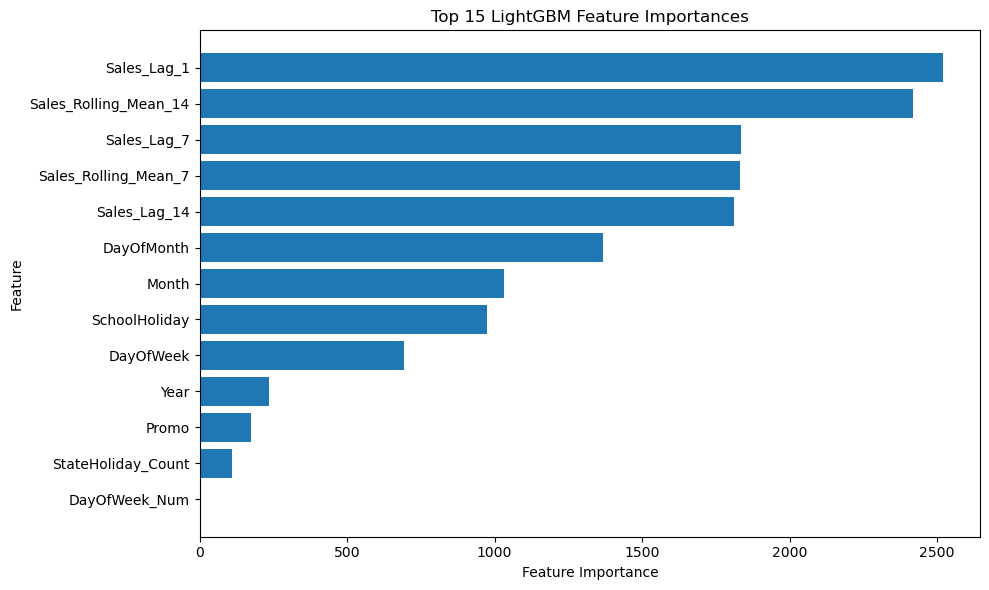

In [591]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 LightGBM Feature Importances")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 15. Actual vs Predicted Sales

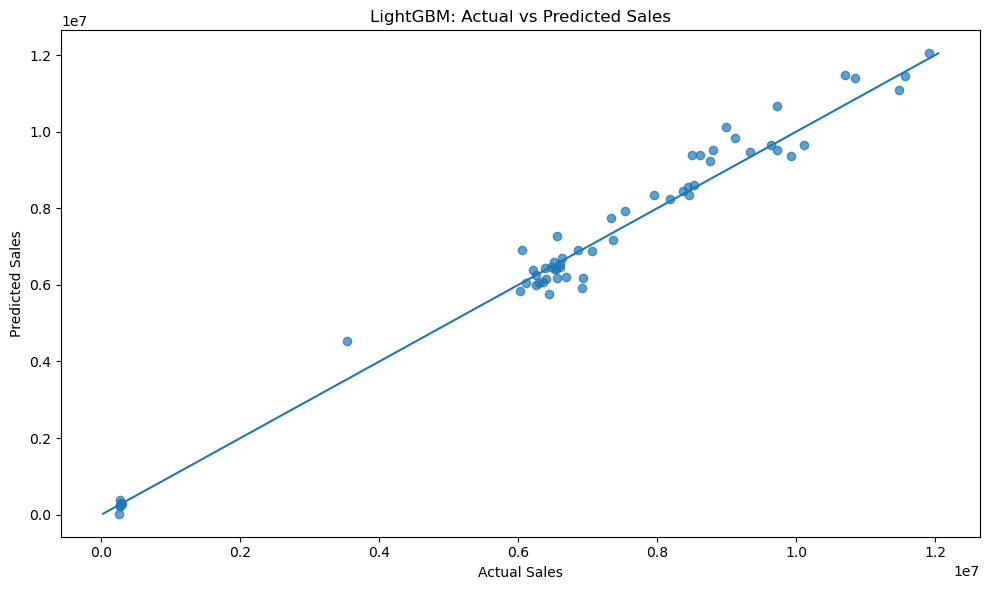

In [592]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("LightGBM: Actual vs Predicted Sales")

# for middle base line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value])

plt.tight_layout()
plt.show()



Interpretations -
* Diagonal line --> when Actual = Predicted
* points close to the line --> good predictions
* points far from the line --> larger errors
* points above the line --> model overpredicted
* points below the line --> model underpredicted
* The vertical line at x = 0 shows when Actual sales = 0

## 16. Actual vs Predicted Sales for One Store

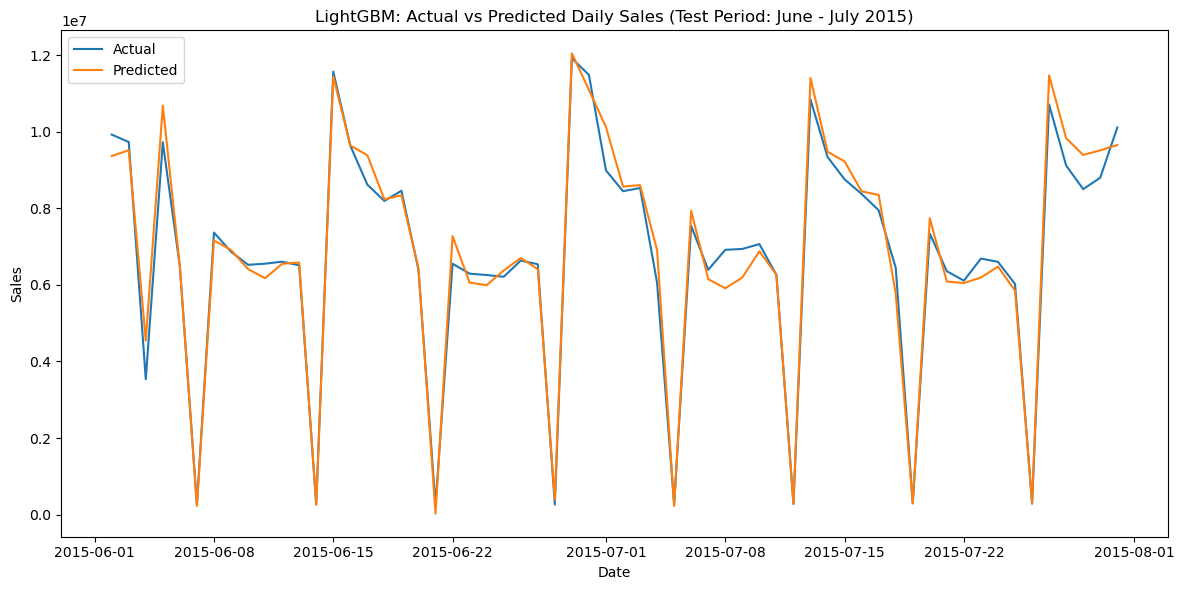

In [593]:
test_results = df.loc[test_mask, ["Date", "Sales"]].copy()
test_results["Predicted"] = y_pred

plt.figure(figsize=(12, 6))
plt.plot(
    test_results["Date"],
    test_results["Sales"],
    label="Actual")

plt.plot(
    test_results["Date"],
    test_results["Predicted"],
    label="Predicted")

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("LightGBM: Actual vs Predicted Daily Sales (Test Period: June - July 2015)")
plt.legend()
plt.tight_layout()
plt.show()

Plot shows strong alignment with Sunday drops and promotional spikes. That pattern is a big part of why DayOfWeek, lags and calendar features are useful

## 17. Summary

### Model

A LightGBM regression model was trained using 13 features, including:

- Sales lag features
- Rolling sales averages
- Calendar features
- Promotion and holiday information

### Evaluation

The model was evaluated using a chronological train-test split to ensure that future observations were not used to train the model.

| Metric | LightGBM |
|---|---:|
| MAE | 323,834.04 |
| RMSE | 451,188.96 |

### Negative Predictions

The model produced zero negative sales predictions on the test set, so no post-processing or clipping was required.

### Key Findings

- LightGBM achieved substantially lower MAE and RMSE than the evaluated classical models on this 60-day holdout period.
- Historical sales features, particularly `Sales_Lag_1`, `Sales_Rolling_Mean_14`, and `Sales_Lag_7`, provided strong predictive signals.
- Calendar features such as `DayOfMonth` and `Month` captured recurring calendar patterns.
- Promotion and holiday counts contributed predictive signal during promotional and holiday periods.

### Conclusion

LightGBM successfully captured relationships between historical sales, calendar patterns, promotions, and holidays.

